In [1]:
pip uninstall -y scikit-learn numpy scipy

Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install numpy==1.26.4 scipy==1.11.4 scikit-learn==1.4.2 imbalanced-learn==0.14.0 --no-cache-dir --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 259.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 193.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 278.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 270.1 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 215.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 389.5 MB/s eta 0:00:00
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully uninstalled threadpoolctl-3.6.0
  Attempting uninstall: joblib
    Found existing installation: joblib 1.5.1
    Uninstalling joblib-1.5.1:
      Successfully uninstalled joblib-1.5.1
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbal

In [3]:
import os
import tensorflow as tf

# Enable dynamic GPU memory allocation
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU found and configured for dynamic memory allocation.")
    except Exception as e:
        print(f"Error configuring GPU, defaulting to CPU. Error: {e}")
        os.environ['CUDA_VISIBLE_DEVICES'] = '-1'
else:
    print("No GPU found. Using CPU.")
    os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

2025-12-28 02:40:05.582554: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766889605.758741      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766889605.811185      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


GPU found and configured for dynamic memory allocation.


In [4]:
import os
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, Bidirectional, LSTM, GRU, Reshape, Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from imblearn.keras import BalancedBatchGenerator
from sklearn.metrics import f1_score

In [5]:
# --- Section 1: Data Loading and Preprocessing ---
import os
import scipy.io
import numpy as np
import gc

base_path = '/kaggle/input/bciaut-p300/data'
all_eeg_data = []
all_eeg_labels = []
all_subject_ids = []
subjects = sorted([d for d in os.listdir(base_path) if d.startswith('SBJ')])
print(f"Found {len(subjects)} subjects. Starting data loading...")

for subject_id in subjects:
    subject_path = os.path.join(base_path, subject_id)
    sessions = sorted([d for d in os.listdir(subject_path) if d.startswith('S')])
    for session_id in sessions:
        train_data_path = os.path.join(subject_path, session_id, 'Train', 'trainData.mat')
        train_labels_path = os.path.join(subject_path, session_id, 'Train', 'trainTargets.txt')
        try:
            eeg_data_dict = scipy.io.loadmat(train_data_path)
            eeg_data = eeg_data_dict['trainData']
            if eeg_data.size == 0:
                print(f"Empty data in {train_data_path}, skipping.")
                continue
            eeg_labels = np.loadtxt(train_labels_path)
            all_eeg_data.append(eeg_data)
            all_eeg_labels.append(eeg_labels)
            subject_numeric_id = int(subject_id.replace("SBJ", ""))
            all_subject_ids.append(
            np.full(len(eeg_labels), subject_numeric_id)
            )
            del eeg_data, eeg_data_dict  # Free memory
            gc.collect()
        except Exception as e:
            print(f"Error loading {session_id}: {e}")
            continue

if all_eeg_data:
    combined_eeg_data = np.concatenate(all_eeg_data, axis=2)
    combined_eeg_labels = np.concatenate(all_eeg_labels)
    combined_subject_ids = np.concatenate(all_subject_ids)
    print("\nData loading complete!")
    print("Shape of combined EEG data:", combined_eeg_data.shape)
    print("Shape of combined labels:", combined_eeg_labels.shape)
    print("Shape of combined subject ids:", combined_subject_ids.shape)
else:
    print("\nNo data was loaded. Please check the file path.")
    raise ValueError("No data loaded, stopping execution.")

Found 15 subjects. Starting data loading...

Data loading complete!
Shape of combined EEG data: (8, 350, 168000)
Shape of combined labels: (168000,)
Shape of combined subject ids: (168000,)


In [6]:
X = np.transpose(combined_eeg_data, (2, 1, 0))
y = combined_eeg_labels.astype(int)
subject_ids = combined_subject_ids

In [7]:
import numpy as np
import scipy.signal as sg
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import gc

In [8]:
SFREQ = 250                     # Hz
WINDOW_START = -200             # in ms (dataset reference only)
CROP_START_MS = 200             # desired window start (200ms)
CROP_END_MS   = 600             # desired window end (600ms)

In [9]:
# dataset samples: -200 ms → 1200 ms = 1400ms total
# 1 ms = SFREQ / 1000 samples

samples_per_ms = SFREQ / 1000
crop_start_idx = int((CROP_START_MS - WINDOW_START) * samples_per_ms)
crop_end_idx   = int((CROP_END_MS   - WINDOW_START) * samples_per_ms)

print("Cropping indices:", crop_start_idx, crop_end_idx)

Cropping indices: 100 200


In [10]:
print("Raw X:", X.shape)

X = X[:, crop_start_idx : crop_end_idx, :]
print("After cropping:", X.shape)


Raw X: (168000, 350, 8)
After cropping: (168000, 100, 8)


In [11]:
def plot_training_history(history, model_name):
    """Plots all available metrics in the training history."""
    available_metrics = list(history.history.keys())
    print(f"Available metrics in history: {available_metrics}")

    plt.figure(figsize=(12, 5))
    # Plot loss
    if 'loss' in available_metrics:
        plt.subplot(1, 2, 1)
        plt.plot(history.history['loss'], label='Training Loss')
        if 'val_loss' in available_metrics:
            plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.title(f'{model_name} Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
    
    # Plot other metrics
    plt.subplot(1, 2, 2)
    metric_plotted = False
    for metric in available_metrics:
        if metric not in ['loss', 'val_loss']:
            plt.plot(history.history[metric], label=f'Training {metric.capitalize()}')
            val_metric = 'val_' + metric
            if val_metric in available_metrics:
                plt.plot(history.history[val_metric], label=f'Validation {metric.capitalize()}')
            metric_plotted = True

    if metric_plotted:
        plt.title(f'{model_name} Metrics')
        plt.xlabel('Epochs')
        plt.ylabel('Metric Value')
        plt.legend()
        plt.grid(True)

    plt.tight_layout()
    plt.show()



# --- Function to plot confusion matrix ---
def plot_confusion_matrix(y_true, y_pred, model_name, labels=['Non-P300', 'P300'], title_suffix=''):
    """
    Generates and displays a confusion matrix plot.
    
    y_true: true labels
    y_pred: predicted labels (can be probabilities or class indices)
    """
    # If y_pred are probabilities, convert to class indices
    if y_pred.ndim > 1 and y_pred.shape[1] > 1:
        y_pred = y_pred.argmax(axis=1)
    
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title(f'Confusion Matrix for {model_name}{title_suffix}')
    plt.show()


In [12]:
# --- Function to adjust threshold and evaluate ---
def adjust_threshold_and_evaluate(y_true_int, y_pred_probs, model_name, threshold):
    """
    Adjusts the classification threshold and prints new performance metrics.
    """
    print(f"\n--- Evaluating {model_name} with Threshold: {threshold} ---")
    y_pred_adjusted = (y_pred_probs[:, 1] > threshold).astype(int)
    
    report = classification_report(y_true_int, y_pred_adjusted, target_names=['Non-P300', 'P300'], output_dict=True)
    print(classification_report(y_true_int, y_pred_adjusted, target_names=['Non-P300', 'P300']))
    
    plot_confusion_matrix(y_true_int, y_pred_adjusted, model_name, title_suffix=f' (Threshold: {threshold})')
    
    return report

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization,
    MaxPooling1D, Flatten, Dense, Dropout
)
from tensorflow.keras.optimizers import Adam


def build_cnn(input_shape, num_classes):

    model = Sequential([
        Input(shape=input_shape),

        Conv1D(32, kernel_size=5, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(64, kernel_size=3, activation='relu'),
        BatchNormalization(),
        MaxPooling1D(2),

        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model


In [16]:
all_y_true = []
all_y_pred = []

loso_results = []
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_cnn(X_train.shape[1:],y_train_cat.shape[1])

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (NO THRESHOLD TUNING)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()



Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2710
F1 Non-P300 : 0.7474

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.4133
F1 Non-P300 : 0.8692

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.2943
F1 Non-P300 : 0.7563

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3539
F1 Non-P300 : 0.8236

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3271
F1 Non-P300 : 0.7344

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2874
F1 Non-P300 : 0.7701

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.3837
F1 Non-P300 : 0.8198

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.4763
F1 Non-P300 : 0.8696

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3189
F1 Non-P300 : 0.7973

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.4305
F1 Non-P300 : 0.8445

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.2973
F1 Non-P300 : 0.6566

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.2971
F1 Non-P300 : 0.7898

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.3196
F1 Non-P300 

In [17]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())



========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.270992    0.747415
1         2  0.413320    0.869185
2         3  0.294261    0.756276
3         4  0.353872    0.823596
4         5  0.327129    0.734371
5         6  0.287388    0.770148
6         7  0.383659    0.819823
7         8  0.476254    0.869648
8         9  0.318863    0.797312
9        10  0.430475    0.844510
10       11  0.297294    0.656609
11       12  0.297130    0.789840
12       13  0.319594    0.798449
13       14  0.282473    0.787830
14       15  0.319132    0.729971

Mean F1 P300     : 0.33812235887621717
Mean F1 Non-P300 : 0.7863323128705487



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.93      0.68      0.79    147000
        P300       0.22      0.64      0.33     21000

    accuracy                           0.68    168000
   macro avg       0.58      0.66      0.56    168000
weighted avg       0.84      0.68      0.73    168000



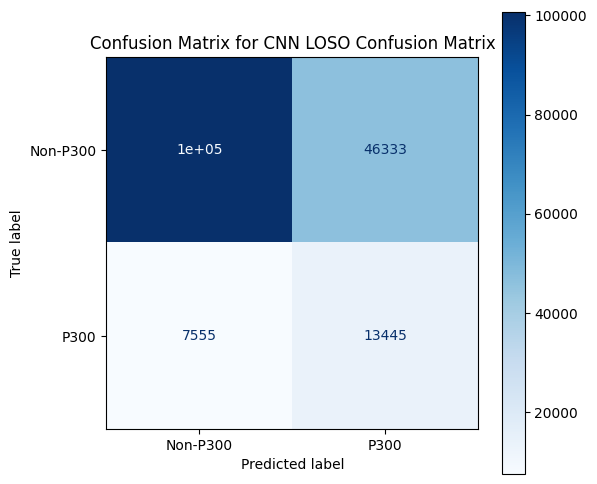

In [19]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "CNN LOSO Confusion Matrix"
)

In [20]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout,
    Bidirectional, LSTM, Dense
)
from tensorflow.keras.optimizers import Adam


def build_bilstm_model(input_shape, num_classes):
    """
    Bi-LSTM model for P300 detection
    input_shape: (time, channels)
    num_classes: 2 (Non-P300, P300)
    """

    input_tensor = Input(shape=input_shape)  # (time, channels)

    # -------------------------
    # CNN front-end
    # -------------------------
    x = Conv1D(filters=32, kernel_size=5, padding='same',
               activation='relu')(input_tensor)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.4)(x)

    # -------------------------
    # Bi-LSTM stack
    # -------------------------
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.4)(x)

    x = Bidirectional(LSTM(16))(x)
    x = Dropout(0.4)(x)

    # -------------------------
    # Classifier
    # -------------------------
    x = Dense(64, activation='relu')(x)
    output_tensor = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output_tensor)

    # -------------------------
    # Compile
    # -------------------------
    model.compile(
        optimizer=Adam(learning_rate=1e-4, clipvalue=1.0),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model


In [21]:
all_y_true = []
all_y_pred = []

loso_results = []
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_bilstm_model(X_train.shape[1:],y_train_cat.shape[1])

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (NO THRESHOLD TUNING)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()



Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2898
F1 Non-P300 : 0.8393

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.4276
F1 Non-P300 : 0.8967

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.3008
F1 Non-P300 : 0.7622

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3706
F1 Non-P300 : 0.8147

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3315
F1 Non-P300 : 0.7718

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.3029
F1 Non-P300 : 0.7610

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.4560
F1 Non-P300 : 0.8817

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.5358
F1 Non-P300 : 0.8927

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3459
F1 Non-P300 : 0.8130

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.4780
F1 Non-P300 : 0.8898

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3395
F1 Non-P300 : 0.8218

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.3423
F1 Non-P300 : 0.8129

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.3209
F1 Non-P300 

In [22]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())



========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.289792    0.839264
1         2  0.427570    0.896712
2         3  0.300792    0.762190
3         4  0.370632    0.814746
4         5  0.331521    0.771783
5         6  0.302850    0.760986
6         7  0.456000    0.881739
7         8  0.535774    0.892651
8         9  0.345853    0.813042
9        10  0.477971    0.889814
10       11  0.339496    0.821769
11       12  0.342270    0.812891
12       13  0.320856    0.792822
13       14  0.276852    0.805957
14       15  0.331338    0.772847

Mean F1 P300     : 0.3633043382872309
Mean F1 Non-P300 : 0.8219474047128199



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.93      0.74      0.82    147000
        P300       0.25      0.61      0.36     21000

    accuracy                           0.72    168000
   macro avg       0.59      0.68      0.59    168000
weighted avg       0.85      0.72      0.77    168000



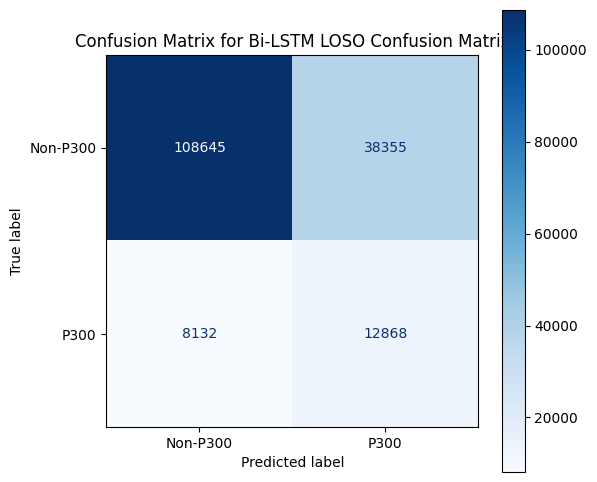

In [23]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "Bi-LSTM LOSO Confusion Matrix"
)


In [24]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    Dense, Multiply, GlobalAveragePooling1D
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_TGT_MHAG_model(input_shape, num_classes):
    """
    TGT-MHAG model builder
    input_shape: (time, channels)
    """

    inp = Input(shape=input_shape)

    # -----------------------------
    # CNN Front-end
    # -----------------------------
    x = Conv1D(32, kernel_size=5, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling1D(pool_size=2)(x)

    # -----------------------------
    # Temporal Gated Attention
    # -----------------------------
    attn = Dense(32, activation='sigmoid')(x)
    x = Multiply()([x, attn])

    # -----------------------------
    # Feature Aggregation
    # -----------------------------
    x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
    x = GlobalAveragePooling1D()(x)

    # -----------------------------
    # Classifier
    # -----------------------------
    x = Dense(64, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inp, outputs=out)

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model

In [25]:
all_y_true = []
all_y_pred = []

loso_results = []
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_TGT_MHAG_model(X_train.shape[1:],y_train_cat.shape[1])

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (NO THRESHOLD TUNING)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()



Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2314
F1 Non-P300 : 0.7654

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.2813
F1 Non-P300 : 0.8306

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.2413
F1 Non-P300 : 0.6185

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.2849
F1 Non-P300 : 0.6956

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.2638
F1 Non-P300 : 0.6113

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2460
F1 Non-P300 : 0.8128

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.2783
F1 Non-P300 : 0.8484

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.3624
F1 Non-P300 : 0.8194

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.2445
F1 Non-P300 : 0.7513

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.3118
F1 Non-P300 : 0.7234

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.2613
F1 Non-P300 : 0.6195

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.2664
F1 Non-P300 : 0.7000

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.2615
F1 Non-P300 

In [26]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.231386    0.765412
1         2  0.281301    0.830584
2         3  0.241260    0.618543
3         4  0.284945    0.695564
4         5  0.263824    0.611323
5         6  0.245961    0.812751
6         7  0.278292    0.848423
7         8  0.362386    0.819364
8         9  0.244456    0.751320
9        10  0.311789    0.723450
10       11  0.261326    0.619547
11       12  0.266380    0.699962
12       13  0.261541    0.740361
13       14  0.238929    0.776719
14       15  0.238851    0.576728

Mean F1 P300     : 0.267508568101072
Mean F1 Non-P300 : 0.7260033613689113



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.91      0.61      0.73    147000
        P300       0.17      0.57      0.27     21000

    accuracy                           0.61    168000
   macro avg       0.54      0.59      0.50    168000
weighted avg       0.82      0.61      0.67    168000



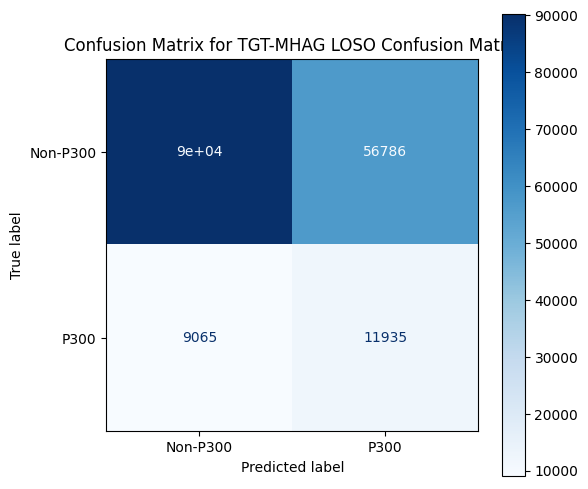

In [27]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "TGT-MHAG LOSO Confusion Matrix"
)


In [28]:
from tensorflow.keras import backend as K

def channel_attention(x, ratio=8):
    ch = x.shape[-1]
    avg = GlobalAveragePooling1D()(x)
    maxp = GlobalMaxPooling1D()(x)
    shared = Dense(ch // ratio, activation='relu')
    avg = Dense(ch)(shared(avg))
    maxp = Dense(ch)(shared(maxp))
    attn = Activation('sigmoid')(avg + maxp)
    return Multiply()([x, attn])

def spatial_attention(x):
    avg = Lambda(lambda z: K.mean(z, axis=-1, keepdims=True))(x)
    maxp = Lambda(lambda z: K.max(z, axis=-1, keepdims=True))(x)
    concat = Concatenate()([avg, maxp])
    attn = Conv1D(1, 7, padding='same', activation='sigmoid')(concat)
    return Multiply()([x, attn])

def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [33]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D, Dropout, Dense,
    GlobalAveragePooling1D, GlobalMaxPooling1D,
    Multiply, Add, Activation, Reshape, Concatenate,
    Bidirectional, LSTM, Lambda
)
from tensorflow.keras import backend as K
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


def build_CBAM_BiLSTM_model(input_shape, num_classes):
    """
    CBAM + BiLSTM model for P300 classification
    input_shape: (time, channels)
    """

    inp = Input(shape=input_shape)

    # CNN + CBAM
    x = Conv1D(32, 5, padding='same', activation='relu')(inp)
    x = cbam_block(x)
    x = MaxPooling1D(2)(x)
    x = Dropout(0.4)(x)

    # BiLSTM stack
    x = Bidirectional(LSTM(32, return_sequences=True))(x)
    x = Dropout(0.4)(x)
    x = Bidirectional(LSTM(16))(x)

    # Classifier
    x = Dense(64, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model

In [34]:
all_y_true = []
all_y_pred = []

loso_results = []
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_CBAM_BiLSTM_model(X_train.shape[1:],y_train_cat.shape[1])

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (NO THRESHOLD TUNING)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2800
F1 Non-P300 : 0.8257

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.4337
F1 Non-P300 : 0.8641

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.3048
F1 Non-P300 : 0.7497

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3749
F1 Non-P300 : 0.8435

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3228
F1 Non-P300 : 0.7093

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.3020
F1 Non-P300 : 0.7489

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.4334
F1 Non-P300 : 0.8402

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.5937
F1 Non-P300 : 0.9215

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3354
F1 Non-P300 : 0.7948

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.4624
F1 Non-P300 : 0.8707

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3364
F1 Non-P300 : 0.7801

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.3286
F1 Non-P300 : 0.7980

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.3126
F1 Non-P300 

In [35]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.279954    0.825728
1         2  0.433679    0.864102
2         3  0.304839    0.749651
3         4  0.374944    0.843474
4         5  0.322830    0.709290
5         6  0.302008    0.748862
6         7  0.433442    0.840201
7         8  0.593716    0.921479
8         9  0.335352    0.794812
9        10  0.462353    0.870687
10       11  0.336442    0.780076
11       12  0.328571    0.798026
12       13  0.312599    0.730898
13       14  0.292595    0.766215
14       15  0.309378    0.724536

Mean F1 P300     : 0.3615135341941241
Mean F1 Non-P300 : 0.7978691948880576



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.94      0.70      0.80    147000
        P300       0.24      0.66      0.35     21000

    accuracy                           0.70    168000
   macro avg       0.59      0.68      0.58    168000
weighted avg       0.85      0.70      0.74    168000



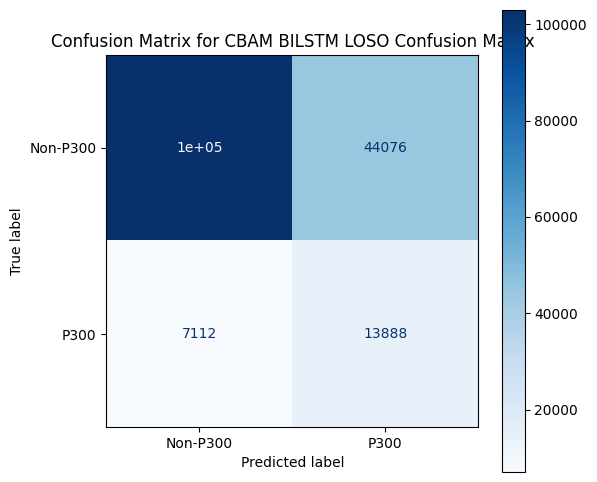

In [36]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "CBAM BILSTM LOSO Confusion Matrix"
)

In [37]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, DepthwiseConv1D, BatchNormalization,
    Activation, Dropout, GlobalAveragePooling1D,
    Dense, Multiply, Add, AveragePooling1D,
    Bidirectional, LSTM
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling1D, Dense, Activation, Multiply, Lambda

def CBAM_Channel_Attention(x, ratio=8):
    channel = x.shape[-1]

    # Global Average Pooling
    avg_out = GlobalAveragePooling1D()(x)
    
    # MLP
    avg_out = Dense(channel // ratio, activation='relu')(avg_out)
    avg_out = Dense(channel)(avg_out)
    
    # Sigmoid + expand dims
    scale = Activation('sigmoid')(avg_out)
    scale = Lambda(lambda s: tf.expand_dims(s, axis=1))(scale)  

    # Scale
    return Multiply()([x, scale])
def MultiScale_Temporal_Block(x, filters):
    conv3 = Conv1D(filters, 3, padding='same', activation='elu')(x)
    conv5 = Conv1D(filters, 5, padding='same', activation='elu')(x)
    conv7 = Conv1D(filters, 7, padding='same', activation='elu')(x)

    x = Add()([conv3, conv5, conv7])
    x = BatchNormalization()(x)
    return x


In [38]:
def build_TGTMHAG_CBAM_BiLSTM(input_shape=(100, 8), num_classes=2):
    inputs = Input(shape=input_shape)

    # ──────────────────────────────
    # Temporal Feature Extraction
    # ──────────────────────────────
    x = Conv1D(32, kernel_size=15, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # Multi-Scale Temporal Learning
    # ──────────────────────────────
    x = MultiScale_Temporal_Block(x, filters=32)

    # ──────────────────────────────
    # Channel Attention (CBAM)
    # ──────────────────────────────
    x = CBAM_Channel_Attention(x, ratio=8)

    # ──────────────────────────────
    # Depthwise Channel Mixing
    # ──────────────────────────────
    x = DepthwiseConv1D(kernel_size=1, depth_multiplier=2)(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    # ──────────────────────────────
    # Temporal Downsampling
    # ──────────────────────────────
    x = AveragePooling1D(pool_size=4)(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # BiLSTM (Latency Handling)
    # ──────────────────────────────
    x = Bidirectional(LSTM(64, return_sequences=True))(x)
    x = Dropout(0.3)(x)

    x = Bidirectional(LSTM(32))(x)
    x = Dropout(0.3)(x)

    # ──────────────────────────────
    # Classifier
    # ──────────────────────────────
    x = Dense(64, activation='elu')(x)
    x = Dropout(0.4)(x)

    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.metrics.AUC(name='auc'),
        tf.metrics.Recall(class_id=1, name='recall_p300'),
        tf.metrics.Precision(class_id=1, name='precision_p300'),
        tf.metrics.Recall(class_id=0, name='recall_nonp300'),
        tf.metrics.Precision(class_id=0, name='precision_nonp300')
        ]
    )

    return model


In [39]:
all_y_true = []
all_y_pred = []

loso_results = []
from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_TGTMHAG_CBAM_BiLSTM(X_train.shape[1:],y_train_cat.shape[1])

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (NO THRESHOLD TUNING)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.3076
F1 Non-P300 : 0.8601

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.4549
F1 Non-P300 : 0.9072

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.2994
F1 Non-P300 : 0.7794

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3780
F1 Non-P300 : 0.8306

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3366
F1 Non-P300 : 0.8363

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.3123
F1 Non-P300 : 0.7646

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.5009
F1 Non-P300 : 0.8974

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.5579
F1 Non-P300 : 0.9029

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3564
F1 Non-P300 : 0.8542

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.4748
F1 Non-P300 : 0.8891

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3540
F1 Non-P300 : 0.7806

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.3397
F1 Non-P300 : 0.8387

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.3274
F1 Non-P300 

In [40]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.307570    0.860102
1         2  0.454880    0.907220
2         3  0.299403    0.779408
3         4  0.377972    0.830626
4         5  0.336567    0.836311
5         6  0.312325    0.764621
6         7  0.500916    0.897357
7         8  0.557897    0.902924
8         9  0.356383    0.854249
9        10  0.474776    0.889105
10       11  0.353998    0.780648
11       12  0.339700    0.838685
12       13  0.327390    0.852086
13       14  0.268212    0.858756
14       15  0.367953    0.815797

Mean F1 P300     : 0.3757294490071558
Mean F1 Non-P300 : 0.8445263144907431



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.93      0.78      0.85    147000
        P300       0.27      0.58      0.37     21000

    accuracy                           0.75    168000
   macro avg       0.60      0.68      0.61    168000
weighted avg       0.85      0.75      0.79    168000



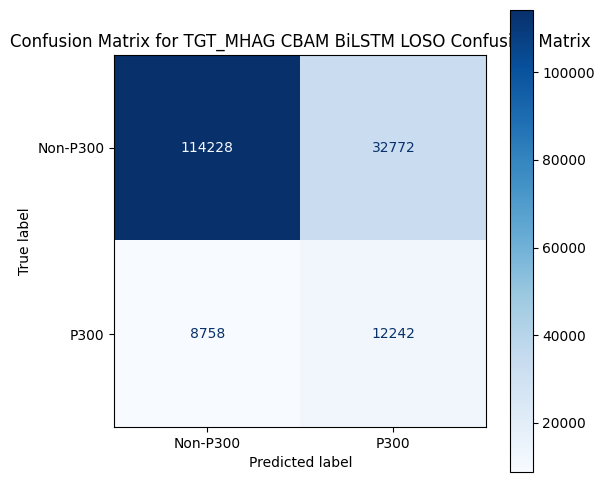

In [41]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "TGT_MHAG CBAM BiLSTM LOSO Confusion Matrix"
)


In [13]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, AveragePooling2D, Dropout,
    Flatten, Dense
)
from tensorflow.keras.models import Model


def build_p3cnet(input_shape, num_classes):
    inp = Input(shape=input_shape)

    # ------------------
    # Temporal filtering
    # ------------------
    k_t1 = max(3, int(input_shape[0] * 0.2))
    x = Conv2D(
        16, (k_t1, 1),
        padding="same",
        activation="relu"
    )(inp)
    x = BatchNormalization()(x)

    # ------------------
    # Spatial filtering
    # ------------------
    x = DepthwiseConv2D(
        (1, input_shape[1]),
        padding="valid",
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    # ------------------
    # Temporal pooling
    # ------------------
    pool_t1 = max(2, input_shape[0] // 30)
    x = AveragePooling2D((pool_t1, 1))(x)
    x = Dropout(0.3)(x)

    # ------------------
    # Higher-level temporal conv
    # ------------------
    k_t2 = max(3, input_shape[0] // 25)
    x = SeparableConv2D(
        32, (k_t2, 1),
        padding="same",
        activation="relu"
    )(x)
    x = BatchNormalization()(x)

    pool_t2 = max(2, input_shape[0] // 40)
    x = AveragePooling2D((pool_t2, 1))(x)
    x = Dropout(0.3)(x)

    # ------------------
    # Classification
    # ------------------
    x = Flatten()(x)
    out = Dense(num_classes, activation="softmax")(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(class_id=1, name="precision_p300"),
            tf.keras.metrics.Recall(class_id=1, name="recall_p300"),
            tf.keras.metrics.Precision(class_id=0, name="precision_nonp300"),
            tf.keras.metrics.Recall(class_id=0, name="recall_nonp300"),
          
        ]
    )

    return model


In [14]:
all_y_true = []
all_y_pred = []

loso_results = []

from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc
import tensorflow as tf
import numpy as np

# ✅ FIX 1: use correct subject id variable
unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # ✅ FIX 2: EXPAND DIMENSION FOR Conv2D
    # Required for P3CNet
    # (samples, time, channels) → (samples, time, channels, 1)
    # -----------------------------
    X_train = X_train[..., np.newaxis]
    X_test  = X_test[..., np.newaxis]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # ONE-HOT (TRAIN ONLY)
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # (compile is INSIDE build function – correct)
    # -----------------------------
    model = build_p3cnet(
        input_shape=X_train.shape[1:],
        num_classes=y_train_cat.shape[1]
    )

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,          # reduced epochs for LOSO ✔
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (FIXED THRESHOLD = 0.5)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP (VERY IMPORTANT FOR LOSO)
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1


I0000 00:00:1766875672.533306      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766875672.533991      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1766875678.963040     126 service.cc:148] XLA service 0x786c58004d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766875678.963657     126 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766875678.963682     126 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766875679.417270     126 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1766875683.385024     126 device_compiler.h:188] Compiled clust

F1 P300     : 0.2838
F1 Non-P300 : 0.7773

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.4317
F1 Non-P300 : 0.8938

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.3271
F1 Non-P300 : 0.8099

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3559
F1 Non-P300 : 0.8387

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3597
F1 Non-P300 : 0.8027

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2873
F1 Non-P300 : 0.7203

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.4467
F1 Non-P300 : 0.8732

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.5986
F1 Non-P300 : 0.9340

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3479
F1 Non-P300 : 0.8256

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.5090
F1 Non-P300 : 0.9060

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3423
F1 Non-P300 : 0.7821

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.3327
F1 Non-P300 : 0.8123

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.3356
F1 Non-P300 : 0.8355

LOSO Fold 14/15
Test Subject: 14
F1 P300     : 0.2960
F1 Non-

In [15]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.283832    0.777316
1         2  0.431651    0.893822
2         3  0.327118    0.809916
3         4  0.355853    0.838738
4         5  0.359742    0.802733
5         6  0.287298    0.720254
6         7  0.446732    0.873182
7         8  0.598609    0.933978
8         9  0.347863    0.825620
9        10  0.509030    0.906016
10       11  0.342304    0.782123
11       12  0.332656    0.812264
12       13  0.335583    0.835468
13       14  0.295979    0.837391
14       15  0.332492    0.736488

Mean F1 P300     : 0.3724494173037122
Mean F1 Non-P300 : 0.8256873016050389



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.93      0.75      0.83    147000
        P300       0.26      0.61      0.36     21000

    accuracy                           0.73    168000
   macro avg       0.59      0.68      0.59    168000
weighted avg       0.85      0.73      0.77    168000



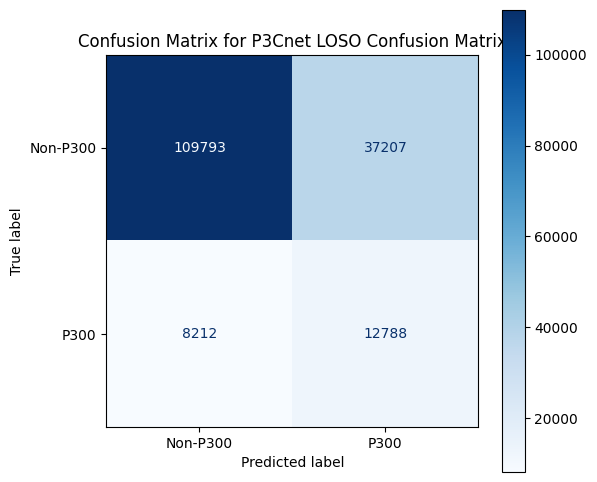

In [16]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "P3Cnet LOSO Confusion Matrix"
)

In [13]:
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, DepthwiseConv2D, SeparableConv2D,
    BatchNormalization, Activation, AveragePooling2D,
    Dropout, Flatten, Dense
)
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm

In [14]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.constraints import max_norm
from tensorflow.keras.optimizers import Adam

def build_EEGNet_model(
    input_shape,
    num_classes,
    F1=8,
    D=2,
    F2=16,
    dropout_rate=0.5,
    learning_rate=1e-3
):
    """
    EEGNet for P300 classification
    Expected input shape: (T, C, 1)
    """

    inp = Input(shape=input_shape)

    # ---------------------------------
    # Block 1: Temporal Convolution
    # ---------------------------------
    x = Conv2D(
        F1,
        (64, 1),
        padding='same',
        use_bias=False
    )(inp)
    x = BatchNormalization()(x)

    # ---------------------------------
    # Block 2: Spatial Filtering
    # ---------------------------------
    x = DepthwiseConv2D(
        (1, input_shape[1]),
        depth_multiplier=D,
        use_bias=False,
        depthwise_constraint=max_norm(1.0)
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = AveragePooling2D((4, 1))(x)
    x = Dropout(dropout_rate)(x)

    # ---------------------------------
    # Block 3: Separable Convolution
    # ---------------------------------
    x = SeparableConv2D(
        F2,
        (16, 1),
        padding='same',
        use_bias=False
    )(x)
    x = BatchNormalization()(x)
    x = Activation('elu')(x)

    x = AveragePooling2D((8, 1))(x)
    x = Dropout(dropout_rate)(x)

    # ---------------------------------
    # Classification
    # ---------------------------------
    x = Flatten()(x)
    out = Dense(
        num_classes,
        activation='softmax',
        kernel_constraint=max_norm(0.25)
    )(x)

    model = Model(inputs=inp, outputs=out, name="EEGNet")

    model.compile(
        optimizer=Adam(learning_rate),
        loss="categorical_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
        ]
    )

    return model


In [15]:
all_y_true = []
all_y_pred = []
loso_results = []

from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # EEGNet SHAPE FIX (CRITICAL)
    # -----------------------------
    X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
    X_test  = X_test[..., np.newaxis]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_EEGNet_model(
        input_shape=X_train.shape[1:],  # (T, C, 1)
        num_classes=2
    )

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,          
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (NO THRESHOLD TUNING)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1


I0000 00:00:1766889690.846858      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1766889690.847489      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1766889696.447531     128 service.cc:148] XLA service 0x7fb4d8015350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766889696.447960     128 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766889696.447972     128 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766889696.821962     128 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1766889700.329314     128 device_compiler.h:188] Compiled clust

F1 P300     : 0.3035
F1 Non-P300 : 0.8412

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.4749
F1 Non-P300 : 0.9057

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.3325
F1 Non-P300 : 0.7889

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3881
F1 Non-P300 : 0.8438

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3774
F1 Non-P300 : 0.8095

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2799
F1 Non-P300 : 0.6797

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.4632
F1 Non-P300 : 0.8773

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.5733
F1 Non-P300 : 0.9293

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3594
F1 Non-P300 : 0.8295

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.4881
F1 Non-P300 : 0.8909

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3491
F1 Non-P300 : 0.7955

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.3303
F1 Non-P300 : 0.8384

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.3414
F1 Non-P300 : 0.8312

LOSO Fold 14/15
Test Subject: 14
F1 P300     : 0.2830
F1 Non-

In [16]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.303511    0.841245
1         2  0.474934    0.905682
2         3  0.332528    0.788858
3         4  0.388145    0.843822
4         5  0.377358    0.809538
5         6  0.279872    0.679696
6         7  0.463163    0.877310
7         8  0.573312    0.929274
8         9  0.359388    0.829527
9        10  0.488053    0.890935
10       11  0.349141    0.795471
11       12  0.330271    0.838413
12       13  0.341357    0.831183
13       14  0.283049    0.855749
14       15  0.348724    0.796743

Mean F1 P300     : 0.3795205030959766
Mean F1 Non-P300 : 0.8342297469820256



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.93      0.76      0.84    147000
        P300       0.27      0.61      0.37     21000

    accuracy                           0.74    168000
   macro avg       0.60      0.68      0.60    168000
weighted avg       0.85      0.74      0.78    168000



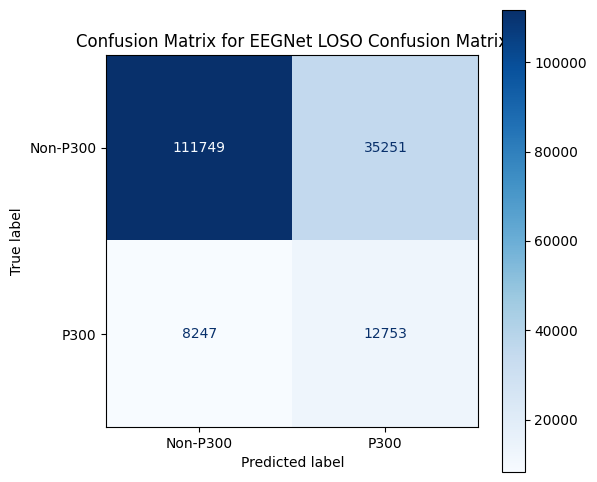

In [17]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "EEGNet LOSO Confusion Matrix"
)

In [18]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

In [19]:
from tensorflow.keras.layers import Lambda, Conv2D, Concatenate, Multiply

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    out = Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    return Multiply()([x, out])
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, GlobalMaxPooling2D, Reshape, Add

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(channel // ratio, activation='relu')
    shared_dense_2 = Dense(channel)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    out = Add()([avg_out, max_out])
    out = Activation('sigmoid')(out)

    out = Reshape((1, 1, channel))(out)
    return Multiply()([x, out])
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [20]:
from tensorflow.keras.layers import Conv2D, BatchNormalization, Add, Activation

def residual_cbam_block(x, filters, stride=1):
    shortcut = x

    x = Conv2D(filters, 3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)

    x = cbam_block(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = Conv2D(filters, 1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([x, shortcut])
    x = Activation('relu')(x)
    return x

In [21]:
def build_cbam_resnet_eeg(input_shape, num_classes):
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,3), padding='same')(inp)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = residual_cbam_block(x, 32)
    x = residual_cbam_block(x, 32)

    x = residual_cbam_block(x, 64, stride=2)
    x = residual_cbam_block(x, 64)

    x = residual_cbam_block(x, 128, stride=2)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300'),
        ]
    )

    return model

In [23]:
all_y_true = []
all_y_pred = []
loso_results = []

from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # SHAPE FIX (CRITICAL)
    # -----------------------------
    X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
    X_test  = X_test[..., np.newaxis]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_cbam_resnet_eeg(
        input_shape=X_train.shape[1:],
        num_classes=2
    )

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (FIXED THRESHOLD)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2768
F1 Non-P300 : 0.7712

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.3848
F1 Non-P300 : 0.9087

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.3023
F1 Non-P300 : 0.7684

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.3108
F1 Non-P300 : 0.7664

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.3513
F1 Non-P300 : 0.8591

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2783
F1 Non-P300 : 0.7496

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.4132
F1 Non-P300 : 0.8653

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.5285
F1 Non-P300 : 0.9025

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.3059
F1 Non-P300 : 0.8291

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.4654
F1 Non-P300 : 0.9171

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3350
F1 Non-P300 : 0.7620

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.3230
F1 Non-P300 : 0.8402

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.2878
F1 Non-P300 

In [25]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.276797    0.771229
1         2  0.384801    0.908690
2         3  0.302346    0.768389
3         4  0.310758    0.766408
4         5  0.351263    0.859099
5         6  0.278336    0.749609
6         7  0.413199    0.865298
7         8  0.528538    0.902548
8         9  0.305920    0.829086
9        10  0.465426    0.917079
10       11  0.335027    0.762003
11       12  0.323048    0.840194
12       13  0.287831    0.607190
13       14  0.269602    0.762468
14       15  0.339919    0.812271

Mean F1 P300     : 0.34485420235899855
Mean F1 Non-P300 : 0.8081040990383983



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.92      0.73      0.81    147000
        P300       0.23      0.58      0.33     21000

    accuracy                           0.71    168000
   macro avg       0.58      0.65      0.57    168000
weighted avg       0.84      0.71      0.75    168000



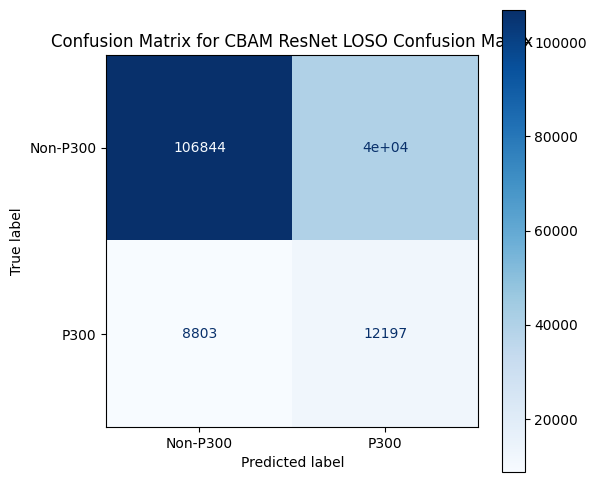

In [24]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "CBAM ResNet LOSO Confusion Matrix"
)

In [26]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, GlobalMaxPooling2D,
    Dense, Reshape, Multiply, Add
)

def channel_attention(x, ratio=8):
    channel = x.shape[-1]

    avg_pool = GlobalAveragePooling2D()(x)
    max_pool = GlobalMaxPooling2D()(x)

    shared_dense_1 = Dense(channel // ratio, activation="relu", use_bias=False)
    shared_dense_2 = Dense(channel, use_bias=False)

    avg_out = shared_dense_2(shared_dense_1(avg_pool))
    max_out = shared_dense_2(shared_dense_1(max_pool))

    attn = Add()([avg_out, max_out])
    attn = tf.keras.activations.sigmoid(attn)
    attn = Reshape((1, 1, channel))(attn)

    return Multiply()([x, attn])
from tensorflow.keras.layers import Lambda, Concatenate, Conv2D

def spatial_attention(x):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(x)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(x)

    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    attn = Conv2D(1, kernel_size=7, padding="same", activation="sigmoid")(concat)

    return Multiply()([x, attn])
def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

In [27]:
from tensorflow.keras.layers import Conv2D, Concatenate

def inception_block(x, filters):
    b1 = Conv2D(filters, (1,1), padding="same", activation="relu")(x)

    b2 = Conv2D(filters, (3,1), padding="same", activation="relu")(x)

    b3 = Conv2D(filters, (5,1), padding="same", activation="relu")(x)

    x = Concatenate(axis=-1)([b1, b2, b3])
    return x

In [28]:
def build_cbam_inception_eeg(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    x = Conv2D(32, (3,1), padding='same', activation='relu')(inp)
    x = BatchNormalization()(x)

    # Inception + CBAM stack
    x = inception_block(x, 16)
    x = cbam_block(x)
    x = Dropout(0.3)(x)

    x = inception_block(x, 32)
    x = cbam_block(x)
    x = Dropout(0.3)(x)

    x = inception_block(x, 64)
    x = cbam_block(x)

    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)
    
    model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(class_id=1, name="precision_p300"),
        tf.keras.metrics.Recall(class_id=1, name="recall_p300"),
        tf.keras.metrics.Precision(class_id=0, name="precision_nonp300"),
        tf.keras.metrics.Recall(class_id=0, name="recall_nonp300"),
    ]
)

    return model


In [30]:
all_y_true = []
all_y_pred = []
loso_results = []

from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # SHAPE FIX (CRITICAL)
    # -----------------------------
    X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
    X_test  = X_test[..., np.newaxis]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_cbam_inception_eeg(
        input_shape=X_train.shape[1:],
        num_classes=2
    )

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (FIXED THRESHOLD)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2524
F1 Non-P300 : 0.7489

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.2435
F1 Non-P300 : 0.8478

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.2548
F1 Non-P300 : 0.8256

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.2669
F1 Non-P300 : 0.8101

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.2385
F1 Non-P300 : 0.7001

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2307
F1 Non-P300 : 0.8303

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.2546
F1 Non-P300 : 0.7325

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.2758
F1 Non-P300 : 0.7472

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.2374
F1 Non-P300 : 0.7226

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.2956
F1 Non-P300 : 0.8415

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.2520
F1 Non-P300 : 0.6583

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.2440
F1 Non-P300 : 0.7651

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.2536
F1 Non-P300 

In [31]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.252441    0.748852
1         2  0.243539    0.847750
2         3  0.254768    0.825649
3         4  0.266927    0.810139
4         5  0.238547    0.700062
5         6  0.230731    0.830318
6         7  0.254564    0.732468
7         8  0.275755    0.747245
8         9  0.237362    0.722635
9        10  0.295576    0.841518
10       11  0.251993    0.658299
11       12  0.244022    0.765054
12       13  0.253602    0.733168
13       14  0.244313    0.769759
14       15  0.192040    0.730488

Mean F1 P300     : 0.24907862271415535
Mean F1 Non-P300 : 0.7642268818018775



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.90      0.67      0.77    147000
        P300       0.17      0.47      0.25     21000

    accuracy                           0.64    168000
   macro avg       0.53      0.57      0.51    168000
weighted avg       0.81      0.64      0.70    168000



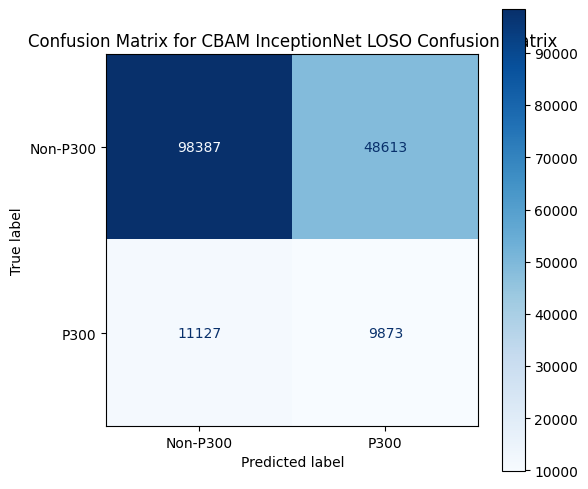

In [32]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "CBAM InceptionNet LOSO Confusion Matrix"
)

In [40]:
from tensorflow.keras.layers import Cropping2D

def crop_to_match(skip, target):
    """
    Crop skip tensor in TIME dimension to match target tensor
    """
    skip_t = skip.shape[1]
    tgt_t  = target.shape[1]

    if skip_t is None or tgt_t is None:
        return skip

    crop = skip_t - tgt_t
    if crop > 0:
        skip = Cropping2D(
            cropping=((crop // 2, crop - crop // 2), (0, 0))
        )(skip)

    return skip
def eeg_conv_block(x, filters):
    x = Conv2D(filters, (3,1), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Conv2D(filters, (3,1), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = cbam_block(x)
    return x


def build_cbam_unet_eeg(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    # ---------- Encoder ----------
    c1 = eeg_conv_block(inp, 32)
    p1 = AveragePooling2D((2,1))(c1)

    c2 = eeg_conv_block(p1, 64)
    p2 = AveragePooling2D((2,1))(c2)

    c3 = eeg_conv_block(p2, 128)
    p3 = AveragePooling2D((2,1))(c3)

    # ---------- Bottleneck ----------
    bn = eeg_conv_block(p3, 256)

    # ---------- Decoder ----------
    u3 = UpSampling2D((2,1))(bn)
    c3_crop = crop_to_match(c3, u3)
    u3 = Concatenate()([u3, c3_crop])
    c4 = eeg_conv_block(u3, 128)

    u2 = UpSampling2D((2,1))(c4)
    c2_crop = crop_to_match(c2, u2)
    u2 = Concatenate()([u2, c2_crop])
    c5 = eeg_conv_block(u2, 64)

    u1 = UpSampling2D((2,1))(c5)
    c1_crop = crop_to_match(c1, u1)
    u1 = Concatenate()([u1, c1_crop])
    c6 = eeg_conv_block(u1, 32)

    # ---------- Classifier ----------
    x = GlobalAveragePooling2D()(c6)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model

In [41]:
all_y_true = []
all_y_pred = []
loso_results = []

from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # SHAPE FIX (CRITICAL)
    # -----------------------------
    X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
    X_test  = X_test[..., np.newaxis]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_cbam_unet_eeg(
        input_shape=X_train.shape[1:],
        num_classes=2
    )

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (FIXED THRESHOLD)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUP
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1
F1 P300     : 0.2349
F1 Non-P300 : 0.7269

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.3312
F1 Non-P300 : 0.8818

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.2520
F1 Non-P300 : 0.7514

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.2913
F1 Non-P300 : 0.7996

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.2969
F1 Non-P300 : 0.7033

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2559
F1 Non-P300 : 0.6588

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.3549
F1 Non-P300 : 0.8505

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.3539
F1 Non-P300 : 0.7799

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.2824
F1 Non-P300 : 0.8476

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.3376
F1 Non-P300 : 0.7575

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.2882
F1 Non-P300 : 0.7106

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.2700
F1 Non-P300 : 0.8113

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.2740
F1 Non-P300 

In [42]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.234895    0.726920
1         2  0.331153    0.881803
2         3  0.252014    0.751442
3         4  0.291270    0.799634
4         5  0.296931    0.703276
5         6  0.255893    0.658810
6         7  0.354923    0.850481
7         8  0.353892    0.779939
8         9  0.282365    0.847586
9        10  0.337554    0.757531
10       11  0.288185    0.710581
11       12  0.270000    0.811348
12       13  0.274001    0.802997
13       14  0.253945    0.835041
14       15  0.285488    0.719234

Mean F1 P300     : 0.29083400267646875
Mean F1 Non-P300 : 0.7757748909443147



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.91      0.68      0.78    147000
        P300       0.20      0.55      0.29     21000

    accuracy                           0.66    168000
   macro avg       0.55      0.61      0.53    168000
weighted avg       0.82      0.66      0.72    168000



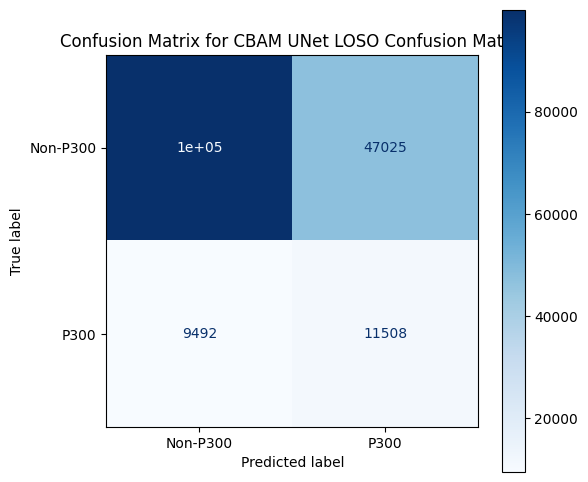

In [43]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "CBAM UNet LOSO Confusion Matrix"
)

In [44]:
def eeg_mbconv(x, filters, expand=4, stride=1):
    in_ch = x.shape[-1]
    exp_ch = in_ch * expand

    # Expansion
    if expand != 1:
        x1 = Conv2D(exp_ch, (1,1), padding='same', use_bias=False)(x)
        x1 = BatchNormalization()(x1)
        x1 = Activation('swish')(x1)
    else:
        x1 = x

    # Depthwise temporal conv
    x1 = DepthwiseConv2D(
        kernel_size=(3,1),
        strides=(stride,1),
        padding='same',
        use_bias=False
    )(x1)
    x1 = BatchNormalization()(x1)
    x1 = Activation('swish')(x1)

    # Projection
    x1 = Conv2D(filters, (1,1), padding='same', use_bias=False)(x1)
    x1 = BatchNormalization()(x1)

    # Skip
    if stride == 1 and in_ch == filters:
        x1 = Add()([x, x1])

    return x1


In [45]:
def build_eeg_efficientnet_cbam(input_shape, num_classes=2):
    inp = Input(shape=input_shape)

    # Stem
    x = Conv2D(32, (5,1), padding='same', activation='swish')(inp)
    x = BatchNormalization()(x)

    # -------- Stage 1 --------
    x = eeg_mbconv(x, 32, expand=1)
    x = cbam_block(x)

    # -------- Stage 2 --------
    x = eeg_mbconv(x, 64, expand=4, stride=2)
    x = eeg_mbconv(x, 64, expand=4)
    x = cbam_block(x)

    # -------- Stage 3 --------
    x = eeg_mbconv(x, 128, expand=6, stride=2)
    x = eeg_mbconv(x, 128, expand=6)
    x = cbam_block(x)

    # -------- Stage 4 --------
    x = eeg_mbconv(x, 192, expand=6, stride=2)
    x = eeg_mbconv(x, 192, expand=6)
    x = cbam_block(x)

    # -------- Head --------
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.4)(x)

    out = Dense(num_classes, activation='softmax')(x)

    model = Model(inp, out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=[
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(class_id=1, name='precision_p300'),
            tf.keras.metrics.Recall(class_id=1, name='recall_p300'),
            tf.keras.metrics.Precision(class_id=0, name='precision_nonp300'),
            tf.keras.metrics.Recall(class_id=0, name='recall_nonp300')
        ]
    )

    return model

In [47]:
all_y_true = []
all_y_pred = []
loso_results = []

from sklearn.metrics import f1_score
from tensorflow.keras.utils import to_categorical
import gc

unique_subjects = np.unique(subject_ids)

print(f"\nStarting LOSO-CV with {len(unique_subjects)} subjects...\n")

for fold, test_subject in enumerate(unique_subjects, 1):

    print(f"\n==============================")
    print(f"LOSO Fold {fold}/{len(unique_subjects)}")
    print(f"Test Subject: {test_subject}")
    print(f"==============================")

    # -----------------------------
    # SPLIT
    # -----------------------------
    test_mask  = subject_ids == test_subject
    train_mask = ~test_mask

    X_train, y_train = X[train_mask], y[train_mask]
    X_test,  y_test  = X[test_mask],  y[test_mask]

    # -----------------------------
    # DOWNSAMPLING (TRAIN ONLY)
    # -----------------------------
    idx_p300    = np.where(y_train == 1)[0]
    idx_nonp300 = np.where(y_train == 0)[0]

    np.random.shuffle(idx_nonp300)
    idx_nonp300 = idx_nonp300[:len(idx_p300)]

    idx_balanced = np.concatenate([idx_p300, idx_nonp300])
    np.random.shuffle(idx_balanced)

    X_train = X_train[idx_balanced]
    y_train = y_train[idx_balanced]

    # -----------------------------
    # SHAPE FIX (CRITICAL)
    # -----------------------------
    X_train = X_train[..., np.newaxis]   # (N, T, C, 1)
    X_test  = X_test[..., np.newaxis]

    # -----------------------------
    # ONE-HOT
    # -----------------------------
    y_train_cat = to_categorical(y_train, 2)

    # -----------------------------
    # BUILD MODEL
    # -----------------------------
    model = build_eeg_efficientnet_cbam(
        input_shape=X_train.shape[1:],
        num_classes=y_train_cat.shape[1]
    )

    # -----------------------------
    # TRAIN
    # -----------------------------
    model.fit(
        X_train,
        y_train_cat,
        epochs=20,
        batch_size=16,
        shuffle=True,
        verbose=0
    )

    # -----------------------------
    # TEST (FIXED THRESHOLD)
    # -----------------------------
    probs_test = model.predict(X_test, verbose=0)[:, 1]
    y_pred = (probs_test >= 0.5).astype(int)

    # -----------------------------
    # METRICS
    # -----------------------------
    f1_p300 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1_nonp300 = f1_score(y_test, y_pred, pos_label=0, zero_division=0)

    print(f"F1 P300     : {f1_p300:.4f}")
    print(f"F1 Non-P300 : {f1_nonp300:.4f}")

    loso_results.append({
        "subject": test_subject,
        "f1_p300": f1_p300,
        "f1_nonp300": f1_nonp300
    })

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

    # -----------------------------
    # CLEANUPi
    # -----------------------------
    del model
    tf.keras.backend.clear_session()
    gc.collect()


Starting LOSO-CV with 15 subjects...


LOSO Fold 1/15
Test Subject: 1


E0000 00:00:1766914214.879154     129 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766914215.020698     129 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766914215.342251     129 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1766914215.482420     129 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


F1 P300     : 0.2224
F1 Non-P300 : 0.7766

LOSO Fold 2/15
Test Subject: 2
F1 P300     : 0.2687
F1 Non-P300 : 0.8375

LOSO Fold 3/15
Test Subject: 3
F1 P300     : 0.2633
F1 Non-P300 : 0.7178

LOSO Fold 4/15
Test Subject: 4
F1 P300     : 0.2890
F1 Non-P300 : 0.8545

LOSO Fold 5/15
Test Subject: 5
F1 P300     : 0.2824
F1 Non-P300 : 0.8453

LOSO Fold 6/15
Test Subject: 6
F1 P300     : 0.2267
F1 Non-P300 : 0.7272

LOSO Fold 7/15
Test Subject: 7
F1 P300     : 0.3224
F1 Non-P300 : 0.7656

LOSO Fold 8/15
Test Subject: 8
F1 P300     : 0.3891
F1 Non-P300 : 0.8526

LOSO Fold 9/15
Test Subject: 9
F1 P300     : 0.2347
F1 Non-P300 : 0.6175

LOSO Fold 10/15
Test Subject: 10
F1 P300     : 0.3601
F1 Non-P300 : 0.8571

LOSO Fold 11/15
Test Subject: 11
F1 P300     : 0.3231
F1 Non-P300 : 0.7769

LOSO Fold 12/15
Test Subject: 12
F1 P300     : 0.2709
F1 Non-P300 : 0.7564

LOSO Fold 13/15
Test Subject: 13
F1 P300     : 0.2792
F1 Non-P300 : 0.7989

LOSO Fold 14/15
Test Subject: 14
F1 P300     : 0.2738
F1 Non-

In [48]:
import pandas as pd

df_loso = pd.DataFrame(loso_results)

print("\n========== LOSO SUMMARY ==========")
print(df_loso)

print("\nMean F1 P300     :", df_loso["f1_p300"].mean())
print("Mean F1 Non-P300 :", df_loso["f1_nonp300"].mean())


========== LOSO SUMMARY ==========
    subject   f1_p300  f1_nonp300
0         1  0.222444    0.776622
1         2  0.268664    0.837516
2         3  0.263336    0.717752
3         4  0.289017    0.854469
4         5  0.282406    0.845281
5         6  0.226674    0.727218
6         7  0.322390    0.765607
7         8  0.389068    0.852599
8         9  0.234695    0.617476
9        10  0.360078    0.857143
10       11  0.323127    0.776947
11       12  0.270945    0.756403
12       13  0.279165    0.798904
13       14  0.273823    0.814130
14       15  0.315190    0.849221

Mean F1 P300     : 0.2880681600086564
Mean F1 Non-P300 : 0.7898191726042685



=== LOSO FINAL REPORT ===
              precision    recall  f1-score   support

    Non-P300       0.91      0.70      0.79    147000
        P300       0.20      0.51      0.28     21000

    accuracy                           0.68    168000
   macro avg       0.55      0.61      0.54    168000
weighted avg       0.82      0.68      0.73    168000



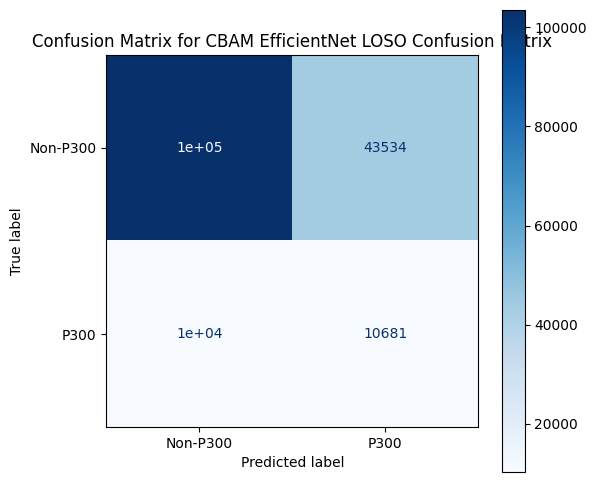

In [49]:
from sklearn.metrics import classification_report

print("\n=== LOSO FINAL REPORT ===")
print(classification_report(
    all_y_true,
    all_y_pred,
    target_names=["Non-P300", "P300"]
))

plot_confusion_matrix(
    np.array(all_y_true),
    np.array(all_y_pred),
    "CBAM EfficientNet LOSO Confusion Matrix"
)